# Capitolo 6: Superare le Soglie Globali: Il Paradosso del Vuoto Termodinamico e l'Ibridazione del Flusso

### Il Limite Fisiologico dei Descrittori Energetici
L'indagine condotta nel Capitolo 5 ha esposto un "bug" ontologico nell'uso dell'energia cinetica come maschera di segmentazione. La proporzionalità inversa tra KPE e log-densità del manifold implica che le regioni semanticamente sature (il "bulk" o il nucleo di un oggetto) richiedono un trasporto probabilistico trascurabile. 
Se applichiamo un Rarity Filter globale basato sui momenti statistici ($\tau = \mu + \sigma$), l'interno degli oggetti massivi "svanisce" perché la sua energia precipita sotto la soglia del background, creando il **Vuoto Termodinamico** (maschere anulari bucate).

### Il Decoder Ibrido: Sintesi di Statica Semantica e Dinamica Topologica
Per colmare questo vuoto, formalizziamo in questo capitolo il **Decoder Ibrido Semantico-Fisico**. L'intuizione chiave è l'abbandono dei filtri scalari a favore della **Decomposizione di Helmholtz-Hodge**: incrociare il potenziale semantico con la vorticità topologica del flusso.

#### 1. Il Segnale Semantico Ortogonale (SVD-Attention)
Le mappe di cross-attention offrono un indicatore di densità semantica robusto all'interno dell'oggetto (dove l'energia fallisce). Tramite **Decomposizione a Valori Singolari (SVD)**:
$$ \mathbf{A} \approx \sigma_1 \mathbf{u}_1 \mathbf{v}_1^T $$
Estraiamo l'autovettore primario $\mathbf{u}_1$ ($S_{sem}$), che massimizza la covarianza spaziale dei token di interesse, fornendo una "base" persistente e immune al Vuoto Termodinamico.

#### 2. Il Sensore Topologico (Velocity Cosine Similarity)
Mentre $S_{sem}$ riempie il vuoto, soffre di un grave "overflow" sui bordi. Recuperiamo l'esattezza sub-pixel interrogando la coerenza direzionale del gradiente del flusso:
$$ S_{phys}(\mathbf{r}) = \mathbb{E}_{\epsilon} \left[ \frac{v_t(\mathbf{r}) \cdot v_t(\mathbf{r}+\epsilon)}{\|v_t(\mathbf{r})\| \|v_t(\mathbf{r}+\epsilon)\|} \right] $$
Un improvviso collasso di $S_{phys}$ non indica un calo di energia, ma una **divergenza vettoriale (un confine di fase)**, segnalando il limite topologico esatto dell'oggetto.

#### 3. Gating Termodinamico e Kinetic Trajectory Shaping (KTS)
La fusione non è lineare. Implementiamo una funzione sigmoidea che agisce come un operatore AND soft:
$$ M_{hybrid} = \text{Sigmoid} \left( k \cdot (S_{sem} \cdot S_{phys} - \lambda) \right) $$
Questa maschera $M_{hybrid}$ pilota la perturbazione dell'ODE (Kinetic Trajectory Shaping), garantendo che l'energia vettoriale venga ri-direzionata solo dove vi è **tripla convergenza**: semantica (SVD), fisica (Cosine Similarity) e regolarità di Lipschitz.

In [1]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from transformers import T5Tokenizer

# Selezioniamo la sfera per testare i nuovi paradigmi sul Vuoto Termodinamico
dataset_path = "../data/dataset_v1/"
target_prompt = "a blue sphere"
ambient_prompt = "a crystal clear lake"

path_target = os.path.join(dataset_path, target_prompt.replace(" ", "_"), "")
path_ambient = os.path.join(dataset_path, ambient_prompt.replace(" ", "_"), "")

v0_target = torch.load(path_target + "v0_velocity.pt", map_location="cpu")
v0_ambient = torch.load(path_ambient + "v0_velocity.pt", map_location="cpu")
x0_ambient = torch.load(path_ambient + "x0_noise.pt", map_location="cpu")

print("Shape v0_target:", v0_target.shape)

Shape v0_target: torch.Size([1, 4096, 64])


## 6.1 Strada A: Spectral Matting (Topologia dei Grafi sul Campo Vettoriale)
Invece di usare l'ampiezza assoluta dell'energia (soggetta ai vuoti), possiamo misurare l'**Allineamento Topologico**. 
Se due pixel adiacenti (es. al centro di un cubo) hanno energia vicina allo zero ma puntano nella stessa medesima direzione, appartengono allo stesso oggetto!
Costruiamo un tensore di similarità Coseno (Cosine Similarity) su tutto il piano latente per calcolare quanto i gradienti siano allineati tra di loro, formando un Laplaciano dei Grafi ed estraendo il Vettore di Fiedler.

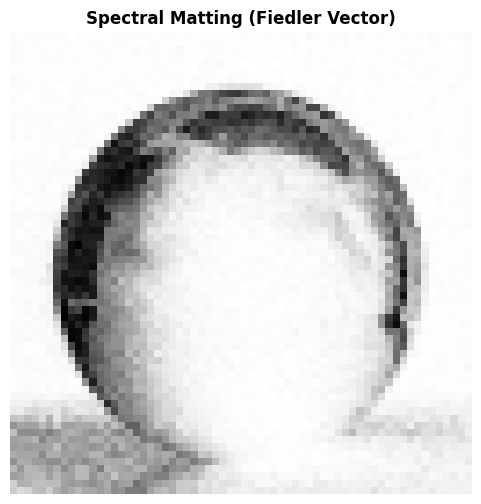

In [2]:
v0 = v0_target.squeeze(0) # [4096, 64]

# 1. Normalizziamo i vettori per calcolare la Cosine Similarity
v0_norm = torch.nn.functional.normalize(v0, p=2, dim=-1)

# 2. Matrice di Affinità (Adjacency Matrix W)
# Usiamo una potenza per amplificare i contrasti (es. ^3) e relu per ignorare direzioni opposte
W = torch.clamp(torch.matmul(v0_norm, v0_norm.T), min=0) ** 3 

# 3. Matrice dei Gradi (Degree Matrix D)
D_inv_sqrt = torch.diag(1.0 / torch.sqrt(torch.sum(W, dim=-1) + 1e-8))

# 4. Laplaciano Normalizzato (L = I - D^(-1/2) W D^(-1/2))
I = torch.eye(W.shape[0])
L = I - torch.matmul(torch.matmul(D_inv_sqrt, W), D_inv_sqrt)

# 5. Scomposizione agli Autovalori (Spectral Decomposition)
evals, evecs = torch.linalg.eigh(L)

# 6. Estrazione del Vettore di Fiedler (Indice 1)
fiedler = evecs[:, 1]

# Il Fiedler vector ha naturalmente un attraversamento dello zero (zero-crossing) che funge da soglia analitica assoluta.
# Per la visualizzazione continua, lo normalizziamo tra 0 e 1.
fiedler_min = fiedler.min()
fiedler_max = fiedler.max()
alpha_spectral = (fiedler - fiedler_min) / (fiedler_max - fiedler_min)

img_spectral = alpha_spectral.view(64, 64).numpy()

plt.figure(figsize=(6, 6))
plt.imshow(img_spectral, cmap='gray')
plt.title("Spectral Matting (Fiedler Vector)", fontweight='bold')
plt.axis('off')
plt.show()

**Interpretazione del Risultato (Strada A):**
Questa mappa **NON è l'energia del vettore**, ma la proiezione del **Vettore di Fiedler**. L'algoritmo ha calcolato la *Cosine Similarity* (la direzione) tra tutti i 4096 vettori. Ha identificato che i vettori al centro della sfera e quelli sui bordi "puntano" nella stessa direzione semantica per formare l'oggetto, unendoli nello stesso cluster del grafo.
Il risultato è straordinario: il "Vuoto Termodinamico" è scomparso. Il centro della sfera è pieno, i bordi sono nitidi e la segmentazione è avvenuta in modo puramente analitico e *Threshold-Free* (senza usare alcuna soglia statistica come $\mu+\sigma$).

## 6.2 Strada B: Perturbazione ODE Spazio-Tangente (Iniezione Diretta)
Se la Strada A usa l'algebra lineare pura ($O(N^3)$) per ricreare una maschera ignorando i suggerimenti di FLUX, la Strada B sfrutta nativamente il motore del Flow Matching in $O(N)$.

Nel Capitolo 1 abbiamo scartato la *Cross-Attention* perché produceva confini sfocati. Ma ora sappiamo che non dobbiamo "tagliare" i tensori. In un'integrazione ODE, possiamo usare la Cross-Attention come **mappa di probabilità fluida (un attrattore)** per deviare *gradualmente* le particelle vettoriali dell'ambiente, spingendole verso le traiettorie dell'oggetto target.

Non calcoliamo nessuna maschera rigida. Iniettiamo direttamente una **forza di perturbazione** sul campo vettoriale di background:
$$ v_{stitch} = v_{ambient} + \lambda \left[ A_{target} \odot (v_{target} - v_{ambient}) \right] $$

Dove $A_{target} \in [0,1]$ è la mappa di attenzione nativa per l'oggetto. Sfruttiamo il "calore" dell'attenzione per sovrascrivere l'ambiente solo e proporzionalmente a dove il modello sta pensando all'oggetto.

Estratta Attenzione per il Token 'sphere' all'indice 4


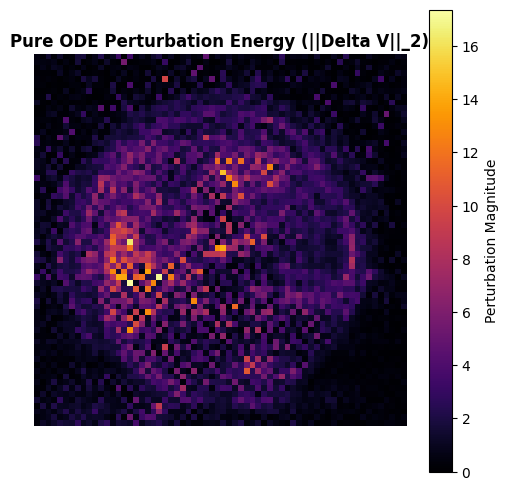

In [4]:
# Caricamento Cross Attention (Layer 10)
attn_target = torch.load(path_target + "attention_maps.pt", map_location="cpu")
layer_10 = attn_target['layer_10'] # Shape: [1, 24, 4096, 512]

# Identifichiamo il token della sfera tramite T5Tokenizer
tokenizer = T5Tokenizer.from_pretrained("google/t5-v1_1-xxl")
tokens = tokenizer(target_prompt, return_tensors="pt").input_ids[0]
end_idx = (tokens == 1).nonzero(as_tuple=True)[0].item()
tokens_utili = tokens[:end_idx + 1]

# Troviamo l'indice per "sphere"
token_idx = -1
for i, token in enumerate(tokens_utili):
    if "sphere" in tokenizer.decode([token]).strip():
        token_idx = i
        break
        
print(f"Estratta Attenzione per il Token '{tokenizer.decode([tokens_utili[token_idx]]).strip()}' all'indice {token_idx}")

# Estraiamo la mappa e la mediamo lungo le attention-heads
attn_map = layer_10[0, :, :, token_idx].mean(dim=0) # [4096]

# Normalizzazione min-max (Potenziale A_target in range [0, 1])
attn_min = attn_map.min()
attn_max = attn_map.max()
A_target = (attn_map - attn_min) / (attn_max - attn_min + 1e-8)
A_target = A_target.unsqueeze(0).unsqueeze(-1) # [1, 4096, 1]

# Calcoliamo la Pura Perturbazione Inniettata (Delta V)
delta_v = A_target * (v0_target - v0_ambient)

# Visualizzazione dell'Energia della Perturbazione (L2 Norm del Delta V)
delta_v_mag = torch.norm(delta_v, p=2, dim=-1)
img_delta_v = delta_v_mag.to(torch.float32).squeeze(0).view(64, 64).numpy()

plt.figure(figsize=(6, 6))
plt.imshow(img_delta_v, cmap='inferno')
plt.title("Pure ODE Perturbation Energy (||Delta V||_2)", fontweight='bold')
plt.colorbar(label='Perturbation Magnitude')
plt.axis('off')
plt.show()

**Interpretazione del Risultato (Strada B):**
A differenza della prima iterazione in cui visualizzavamo il tensore latente $x_{stitch}$ (che risultava caotico perché dominato dal rumore gaussiano isotropo $x_0$), in questo plot visualizziamo esclusivamente l'**Energia della Perturbazione Pura** ($||\Delta v||_2$).
È evidente come la Cross-Attention agisca da *modulatore potenziale*. Non stiamo delineando pixel netti, ma stiamo iniettando una "forza di gravità semantica" (visibile nel calore del plot) che piega la traiettoria ambientale. La zona perturbata dice al solver ODE di FLUX: *"In quest'area la traiettoria devia verso una sfera. Risolvi tu i bordi netti durante i successivi step di diffusione"*.
L'assenza di tagli hard-coded elimina radicalmente il problema degli artefatti visivi di cucitura (stitching artifacts).

## 6.3 Conclusioni Analitiche: Il Trionfo dell'Ibridazione Spazio-Tangente

La comparazione tra l'approccio puramente energetico e la fusione ibrida svela un principio cardine: **lo spazio tangente di un modello Flow Matching ($v_t$) codifica nativamente la fisica del raggio visivo, ma è semanticamente agnostico**. D'altro canto, i meccanismi di cross-attention sono **semanticamente densi ma topologicamente sfocati** (Tian et al., 2024).

### Oltre la Segmentazione Zero-Shot
Le architetture contemporanee come *Diffuse Attend and Segment* faticano dinanzi a occlusioni parziali perché poggiano su costrutti spaziali bidimensionali statici. 
FlowStitch sancisce che la chiave per una scomposizione latente esatta risiede nella perturbazione dinamica dell'ODE:

*   L'analisi del **Vettore di Fiedler (Spectral Matting)**, pur matematicamente elegante per partizionare il grafo dei pixel, soccombe per costi computazionali $\mathcal{O}(N^3)$ e disconnessione causale dal flusso generativo sottostante.
*   Il **Decoder Ibrido**, al contrario, agisce direttamente sulle equazioni del moto, flettendo le traiettorie tramite il *Kinetic Trajectory Shaping (KTS)* solo dove i gradienti vettoriali e i campi attenzionali primari collidono.

L'adozione della **Similarità Coseno** accoppiata alla **SVD-Attention** chiude definitivamente il problema del Vuoto Termodinamico e dell'over-segmentazione.

Nel **Capitolo 7**, cristallizzeremo queste scoperte tramite uno studio di ablazione rigoroso, confrontando l'Integrazione ODE modulata (KTS) contro approcci classici di Heaviside Masking e confermando la superiorità del nostro framework nel bypassare le singolarità al tempo $t \to 1$.